#First

In [9]:
import pandas as pd
import torch

# This automatically detects if a GPU (CUDA) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the train and test files
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Look at the first 5 rows of your training data
print(train.head())

# Check how much data you have
print(f"\nTraining set size: {len(train)} rows")


Using device: cpu
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Training set size: 120000 rows


Class Distribution:
Class Index
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64


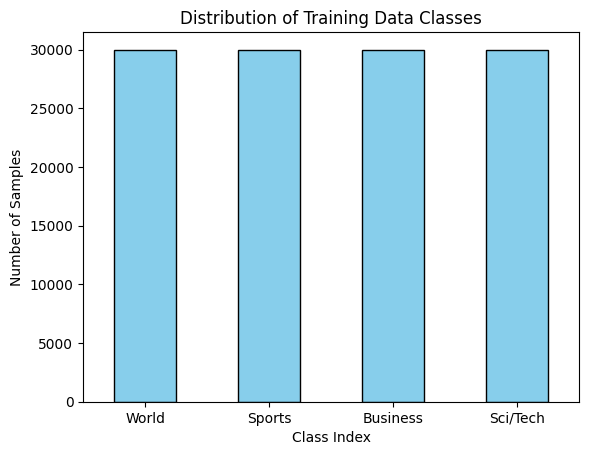

In [10]:
import matplotlib.pyplot as plt

# This dictionary is the "translation table": number → name
CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

# Count occurrences of each class index
class_counts = train["Class Index"].value_counts().sort_index()

#  swap out the numeric index for the names
class_counts.index = class_counts.index.map(CLASS_NAMES)
print("Class Distribution:")
print(class_counts)

# Visualize the distribution
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Training Data Classes")
plt.xlabel("Class Index")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np


class ModelEvaluator:
    def __init__(self, y_true, y_pred, class_names=list(CLASS_NAMES.values())):
        """
        y_true and y_pred should be numpy arrays or lists.
        class_names: list of strings (e.g., ["Sports", "World", ...])
        """
        self.y_true = y_true
        self.y_pred = y_pred
        self.class_names = (
            class_names
            if class_names
            else [f"{i + 1}" for i in range(len(np.unique(y_true)))]
        )

    def show_report(self):
        print("\n--- Classification Report ---")
        print(
            classification_report(
                self.y_true, self.y_pred, target_names=self.class_names
            )
        )

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.class_names,
            yticklabels=self.class_names,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    def plot_f1_scores(self):
        f1_scores = f1_score(self.y_true, self.y_pred, average=None) * 100

        min_score = min(f1_scores)
        max_score = max(f1_scores)

        padding = 5
        bottom = max(0, min_score - padding)
        top = min(100, max_score + padding)

        plt.figure(figsize=(10, 5))
        plt.bar(self.class_names, f1_scores, color="skyblue")
        plt.ylabel("F1-Score (%)")
        plt.title("F1-Score per Class")
        plt.ylim(bottom, top)
        plt.show()

    def save_errors(self, texts, filename="model_errors.csv"):
        """
        Filters wrong predictions and saves them to a CSV with readable labels.
        texts: list or array of the original input strings
        """
        # Create a dataframe for easy handling
        df = pd.DataFrame(
            {"text": texts, "actual_idx": self.y_true, "predicted_idx": self.y_pred}
        )

        # Filter for errors
        errors = df[df["actual_idx"] != df["predicted_idx"]].copy()

        # Map indices to names if possible
        if self.class_names:
            errors["actual_label"] = [self.class_names[i-1] for i in errors["actual_idx"]]
            errors["predicted_label"] = [self.class_names[i-1] for i in errors["predicted_idx"]]

        final_errors = pd.DataFrame(
            {
                "text": errors["text"],
                "Actual Class": errors["actual_label"],
                "Predicted Class": errors["predicted_label"],
            }
        )
        final_errors.to_csv(filename, index=False)
        print(f"Success: {len(errors)} errors saved to '{filename}'")
        return final_errors

In [12]:
# Combine Title and Description into a single 'text' column
train["text"] = train["Title"] + " " + train["Description"]
test["text"] = test["Title"] + " " + test["Description"]

# Keep only the columns we need (the Class index and the combined text)
train ["Label Name"]= train["Class Index"].map(CLASS_NAMES) #class name added 

test = test[["Class Index", "text"]]

# shuffle the data so there isn't any bias 
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the first few rows
print(train[["Label Name", "text"]].head())

  Label Name                                               text
0   Business  BBC set for major shake-up, claims newspaper L...
1   Business  Marsh averts cash crunch Embattled insurance b...
2     Sports  Jeter, Yankees Look to Take Control (AP) AP - ...
3   Sci/Tech  Flying the Sun to Safety When the Genesis caps...
4   Business  Stocks Seen Flat as Nortel and Oil Weigh  NEW ...


In [13]:

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC



# 2. Define your Pipeline
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english", 
        sublinear_tf=True, 
        min_df=2,
        max_features=30000)), 
        ("clf", LinearSVC()),
    ]
#: Enhancement 1: log-scale term freq
# Enhancement 2 :# ignore terms in fewer than 2 documents (noise)
# Enhancement 3 : Increase num of features to 30000 because 5000 is not enough
)


# 3. Use cross_val_score on the 80% (X_train_val)
# This automates the internal training/testing folds for you.
cv_scores = cross_val_score(
    pipeline, train["text"], train["Class Index"], cv=5, scoring="f1_macro"
)
print(f"Mean CV Score: {cv_scores.mean():.4f}")

# 4. Final Evaluation (Only after tuning is done)
pipeline.fit(train['text'], train['Class Index'])
final_score = pipeline.score(test['text'], test['Class Index'])
print(f"Final Hold-out Score: {final_score:.4f}")

Mean CV Score: 0.9195
Final Hold-out Score: 0.9212



--- Classification Report ---
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.90      0.88      0.89      1900
    Sci/Tech       0.89      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



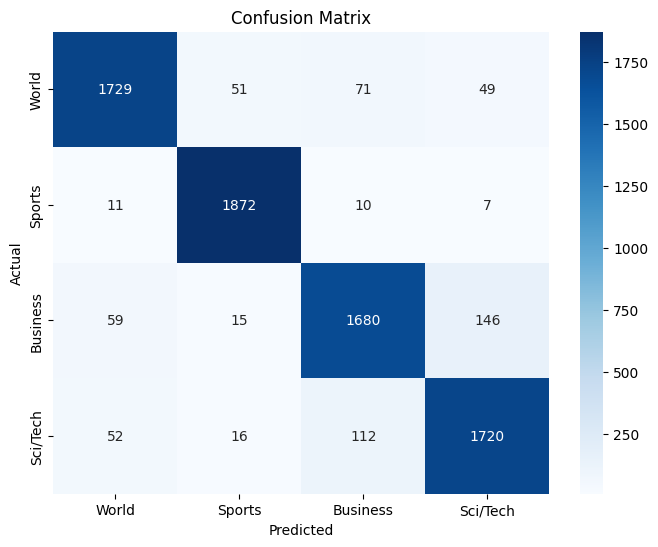

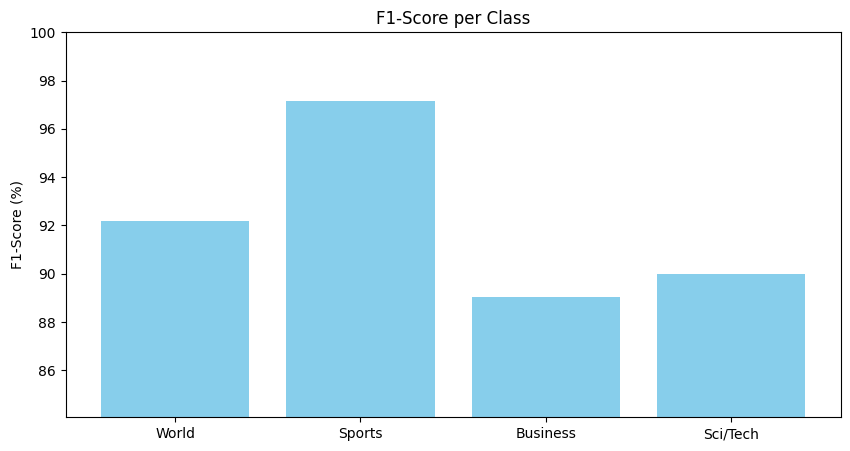

In [20]:
# 1. Generate predictions
tfidf_preds = pipeline.predict(test["text"])
tfidf_labels = test["Class Index"]  

# 2. Initialize the evaluator
evaluator = ModelEvaluator(
    y_true=tfidf_labels,
    y_pred=tfidf_preds,
)

# 3. Call the methods
evaluator.show_report()
evaluator.plot_confusion_matrix()
evaluator.plot_f1_scores()


DistilBert Emeddings

In [15]:
from transformers import DistilBertModel

# Load DistilBERT just to steal its embedding table

print("Extracting BERT embedding weights...")
bert_for_embeddings = DistilBertModel.from_pretrained("distilbert-base-uncased")

# .numpy() converts it to a numpy array so we can pass it around easily
bert_embedding_matrix = (
    bert_for_embeddings
    .embeddings
    .word_embeddings
    .weight
    .detach()
    .numpy()
)

print(f"Embedding matrix shape: {bert_embedding_matrix.shape}")
# Should print: (30522, 768) 
#30522 vocab size 
#768 vector length per word

# Free the memory — we only needed the weights, not the full BERT model
del bert_for_embeddings
print("Done. BERT model released from memory.")

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting BERT embedding weights...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4000.10it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: (30522, 768)
Done. BERT model released from memory.


LSTM

In [16]:
import torch
import torch.nn as nn


class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,dropout=0.5 , num_layers=2,pretrained_embeddings=None):
        super(LSTM, self).__init__()

        # 1. Embedding Layer: Converts integer IDs to vectors
        # padding_idx=0 tells the model to ignore padding tokens
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            # Load the BERT embedding matrix into our table

            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_embeddings, dtype=torch.float32)
            )

            # Allowing small updates lets them adapt to news classification
            self.embedding.weight.requires_grad = True
        
        # 2. LSTM Layer: Processes the sequence
        # dropout layer to not rely on certain neurons during training
        self.dropout_layer = nn.Dropout(dropout)
        # batch_first=True means input shape is (batch, seq_len, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0 )

        # 3. Linear Layer: Maps final hidden state to the 4 classes 
        # The *2 is for the bidirectional
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)
        # output: [batch_size, seq_len, hidden_dim]
        # (hidden, cell): state of the LSTM at the end of the sequence
        output, (hidden, cell) = self.lstm(embedded)

        # We take the final hidden state [-1] for classification
        # hidden shape: [1, batch_size, hidden_dim]
        # last_hidden = self.dropout_layer(hidden[-1])

        # Concatenate the forward [-2] and backward [-1] hidden states
        # Result shape: [batch_size, hidden_dim * 2]
        last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        last_hidden = self.dropout_layer(last_hidden)

        return self.fc(last_hidden)


Train Function LSTM

In [17]:
import torch.optim as optim


# --- DEFINE TRAINING FUNCTION ---
def train_model(model, loader, criterion, optimizer,device):
    model.train()  
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()  # Clear gradients
        predictions = model(x_batch)  # Forward pass
        loss = criterion(predictions, y_batch)  # Calculate loss
        loss.backward()  # Backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
        optimizer.step()  # Update weights

        total_loss += loss.item()

    return total_loss / len(loader)


# --- DEFINE EVALUATION FUNCTION ---
def evaluate_model(model, loader, criterion,device):
    model.eval()  
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # No gradients needed for testing
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item()

            
            _, predicted = torch.max(predictions, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return total_loss / len(loader), correct / total


Dataset Class



In [18]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader , random_split

# 1. HuggingFace Tokenizer (The "Processor")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(len(tokenizer.vocab))

# 2. PyTorch Dataset & LSTM Model
class TextDataset(Dataset):
    def __init__(self, df, max_len=64):
        self.texts = df["text"].values
        self.labels = df["Class Index"].values - 1  # Assuming 1-based indexing
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Convert text to numerical IDs
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        return encoding["input_ids"].squeeze(), torch.tensor(self.labels[idx])
        #Removes extra dimensions : like turning a 1x64 list into a simple 64 list

30522


In [19]:
# Create datasets
train_dataset = TextDataset(train, max_len=128)
test_dataset = TextDataset(test, max_len=128)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size #validation

# 3. Split the data
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)